# Question 1 : Load and Visualize a Time Series Dataset
Load the "AirPassengers" dataset and plot the time series.

Dataset : https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates = True, index_col = 'Month')
df


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


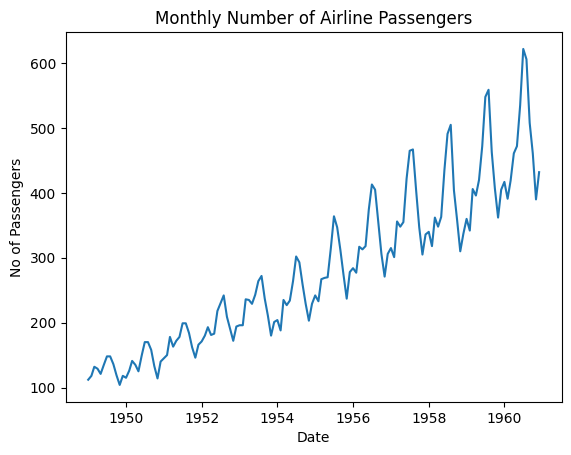

In [2]:
plt.style.use('default')
plt.plot(df.index, df['Passengers'])
plt.xlabel('Date')
plt.ylabel('No of Passengers')
plt.title('Monthly Number of Airline Passengers')
plt.show()


# Question 2 : Check for Missing Values and Summary Stats
Display missing values and basic statistics for the “AirPassengers” dataset

In [3]:
from data_analysis_utils import Univariate as univ, Preprocessing as prep, NormalDistribution as norm

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [4]:
quan,qual=prep.quanQual(df)
print('Quantitative',quan,'\nQualitative',qual)
des_data=univ.descriptive(df,quan)
des_data


Quantitative Index(['Passengers'], dtype='object') 
Qualitative Index([], dtype='object')


,Passengers
Mean,280.3
Mode,229
Min,104
Q1-25th%,180.0
Median / Q2-50%,265.5
Q3-75th%,360.5
99th%,585.79
Max-100th%,622
IQR,180.5
1.5rule,270.75


# Question 3 : Decompose the Time Series
Decompose the time series into trend, seasonality, and residuals for the “AirPassengers” dataset.

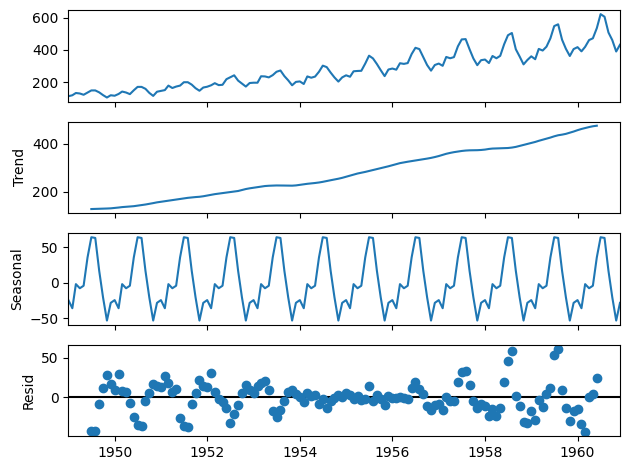

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
plt.style.use('default')

decomposition = seasonal_decompose(df, model='additive', period=12)
decomposition.plot()
plt.tight_layout()
plt.show()


# Question 4 : Check Stationarity with Augmented Dickey-Fuller Test
Check if the time series is stationary for the above dataset.

In [6]:

from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

dftest = adfuller(df['Passengers'].dropna(), autolag='AIC')

test_stat = dftest[0]
p_val = dftest[1]
used_lag = dftest[2]
nobs = dftest[3]
crit_vals = dftest[4]

dfoutput = pd.Series({
    'Test Statistic': test_stat,
    'p-value': p_val,
    '#Lags Used': used_lag,
    'Observations': nobs,
    'Critical Value (1%)': crit_vals['1%'],
    'Critical Value (5%)': crit_vals['5%'],
    'Critical Value (10%)': crit_vals['10%']
})

print(dfoutput)

if test_stat < min(crit_vals.values()) and p_val < 0.05:
    print(f"\nSeries is Stationary as \nTest Statistic {test_stat.round(4)} < Critical Value {min(np.round(list(crit_vals.values()), 4))} and \nP-Value {p_val.round(4)} < 0.05")
else:
    print(f"\nSeries is Non-Stationary as \nTest Statistic {test_stat.round(4)} >= Critical Value {min(np.round(list(crit_vals.values()), 4))} or \nP-Value {p_val.round(4)} >= 0.05")


Test Statistic            0.815369
p-value                   0.991880
#Lags Used               13.000000
Observations            130.000000
Critical Value (1%)      -3.481682
Critical Value (5%)      -2.884042
Critical Value (10%)     -2.578770
dtype: float64

Series is Non-Stationary as 
Test Statistic 0.8154 >= Critical Value -3.4817 or 
P-Value 0.9919 >= 0.05


# Question 5 : Split the Dataset into Train and Test
Split the time series into 80% train and 20% test for the above dataset.

In [8]:
train_size = int(len(df)*0.80)
train = df['Passengers'].iloc[:train_size]
test  = df['Passengers'].iloc[train_size:]
